## MSE losses

In [1]:
%run -i imports.py
cmap = cmc.lajolla
%matplotlib inline

2026-08-14 11:10:45.303200: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-08-14 11:10:45.303285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-08-14 11:10:45.304921: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Python==3.10.13

numpy==1.26.2
pandas==2.1.3
scipy==1.11.4
scikit-learn==1.3.2
PCAfold==2.2.0


In [2]:
data_type = 'FPF'
data_tag = 'oxyfuel'
target_variables_indices = [0, 2, 3, 5, 6, 9, 10]
results_dir = '../scripts/'
pure_streams = True
%run -i ../scripts/fpf-load-data.py


Using: T, O2, OH, H2, H2O, CO, CO2 as target state variables at the decoder output.

25829 observations
27 state variables


In [4]:
random_seed = 0

In [5]:

training_losses_across_epochs = pd.read_csv(results_dir + 'f-PV-' + pure_streams_prefix + '-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-MSE-training-losses-rs-' + str(random_seed) + '.csv', sep = ',', header=None).to_numpy()

In [7]:
CMP_training_losses_across_epochs = pd.read_csv(results_dir + 'f-PV-tps-FPF-oxyfuel-target-T-O2-OH-H2-H2O-CO-CO2-RandomNormal-e-300000-CD-300000-lr-0.01-alr-0.001-scale-none-darch-0-10-10-rho-0.9-mom-0.5-momcent-no-MSE-validation-losses-rs-' + str(random_seed) + '.csv', sep = ',', header=None).to_numpy()

Text(0, 0.5, 'MSE loss')

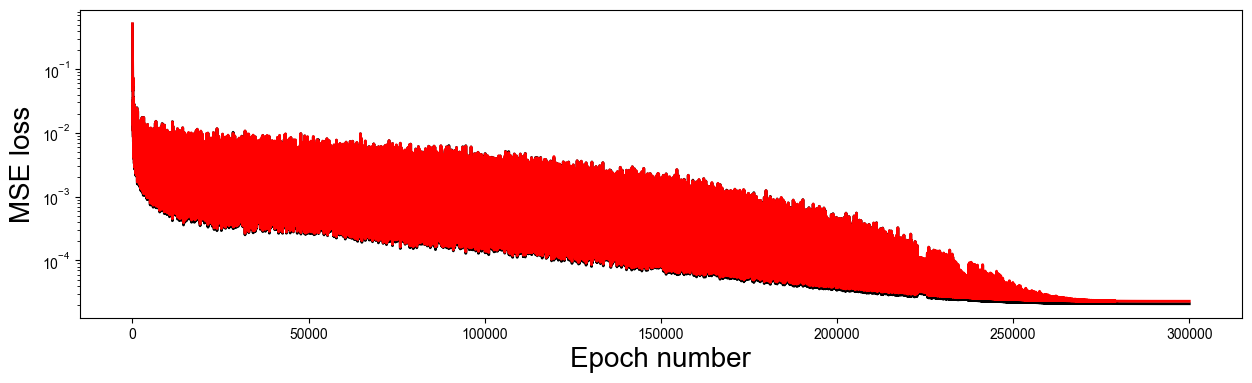

In [8]:
fig = plt.figure(figsize=(15,4))
y = np.arange(0,training_losses_across_epochs.shape[0],1)
plt.semilogy(y, training_losses_across_epochs, lw=2, c='k')
plt.semilogy(y, CMP_training_losses_across_epochs, lw=2, c='r')
plt.xlabel('Epoch number', fontsize=20)
plt.ylabel('MSE loss', fontsize=20)